In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, NullLocator

base = Path("..") / "pd_runs"

METRIC_COLUMNS = {
    "score_continuous": "Continuous",
    "score_poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
    "score_poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
    "score_poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
}

ROW_SPECS = [
    {"targets": ["inp"], "markers": {"inp": "o"}, "ylabel": "truth input"},
    {
        "targets": ["cumsum", "sign_cumsum"],
        "markers": {"cumsum": "^", "sign_cumsum": "s"},
        "ylabel": "cumsum / sign(cumsum)",
    },
]


def load_results(name: str) -> pd.DataFrame:
    df = pd.read_csv(base / name / "decodability_results.csv")
    df.columns = df.columns.str.strip()
    df["seed"] = df["run_name"].str.extract(r"_seed(\d+)_").astype(int)
    return df


hs_ws_df = load_results("hs_ws_runs")
noise_df = load_results("noise_runs")
small_df = load_results("small_runs")

hs_ws_df.shape, noise_df.shape, small_df.shape


((180, 13), (216, 13), (324, 13))

In [2]:
def plot_decodability(df, x_col, group_col, group_prefix, xlabel, title):
    """2x4 P vs D decodability plot: rows=targets, cols=metrics."""
    x_vals = sorted(df[x_col].unique())
    groups = sorted(df[group_col].unique())
    colors = {g: f"C{i}" for i, g in enumerate(groups)}
    seeds = sorted(df["seed"].unique())

    fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=False)

    for row, spec in enumerate(ROW_SPECS):
        for col, (metric, metric_label) in enumerate(METRIC_COLUMNS.items()):
            ax = axes[row, col]
            for target in spec["targets"]:
                sub = df[df["target"] == target]
                marker = spec["markers"][target]
                for g in groups:
                    g_sub = sub[sub[group_col] == g]
                    for area, ls in [("P", "-"), ("D", ":")]:
                        area_sub = g_sub[g_sub["decode_from"] == area]
                        mean = area_sub.groupby(x_col)[metric].mean().sort_index()
                        lo = area_sub.groupby(x_col)[metric].min().sort_index()
                        hi = area_sub.groupby(x_col)[metric].max().sort_index()
                        show_legend = row == 0 and col == 0 and area == "P" and target == spec["targets"][0]
                        ax.plot(
                            mean.index,
                            mean.values,
                            marker=marker,
                            linestyle=ls,
                            color=colors[g],
                            label=f"{group_prefix}={g}" if show_legend else "_nolegend_",
                        )
                        ax.fill_between(
                            mean.index,
                            lo.values,
                            hi.values,
                            color=colors[g],
                            alpha=0.12 if area == "P" else 0.06,
                        )

            if x_col == "noise_p":
                ax.set_xscale("log")
                ax.xaxis.set_major_locator(FixedLocator(x_vals))
                ax.xaxis.set_minor_locator(NullLocator())
                ax.set_xticklabels([str(v) for v in x_vals], rotation=45, ha="right")
            else:
                ax.set_xticks(x_vals)
                ax.set_xticklabels([str(v) for v in x_vals], rotation=45, ha="right")

            if row == 0:
                ax.set_title(metric_label)
            if row == 1:
                ax.set_xlabel(xlabel)
            if col == 0:
                ax.set_ylabel(spec["ylabel"] + "\n" + r"$R^2$")

    handles, _ = axes[0, 0].get_legend_handles_labels()
    style_handles = [
        Line2D([0], [0], color="k", linestyle="-", label="P"),
        Line2D([0], [0], color="k", linestyle=":", label="D"),
        Line2D([0], [0], color="k", marker="^", linestyle="None", label="cumsum"),
        Line2D([0], [0], color="k", marker="s", linestyle="None", label="sign(cumsum)"),
    ]
    axes[0, 0].legend(handles=handles + style_handles, loc="best")
    fig.suptitle(f"{title} (mean with min–max over seeds {seeds})")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


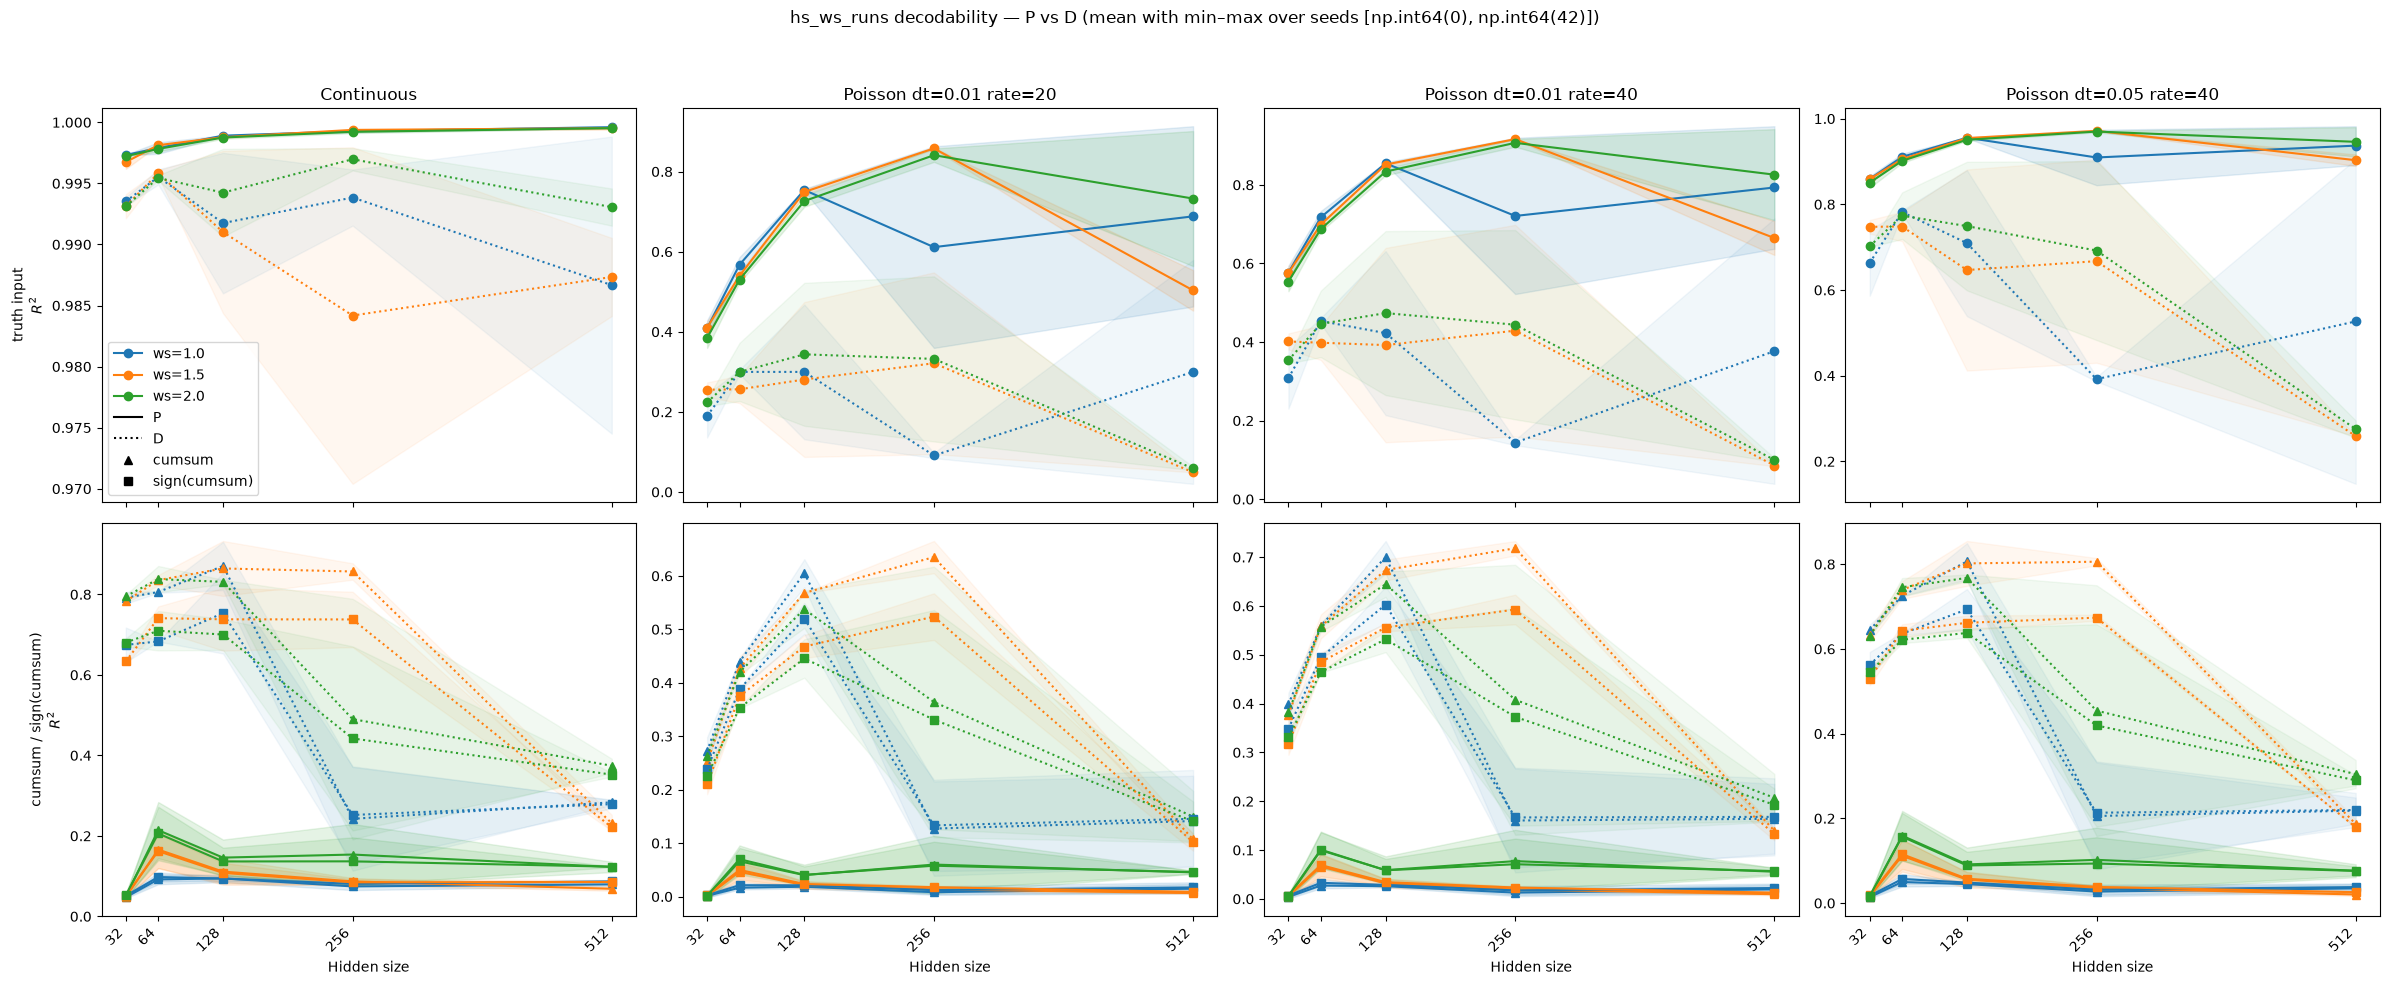

In [3]:
# hs_ws_runs: R^2 vs hidden size, colored by weight scale
plot_decodability(
    hs_ws_df,
    x_col="hidden_size",
    group_col="ws",
    group_prefix="ws",
    xlabel="Hidden size",
    title="hs_ws_runs decodability — P vs D",
)


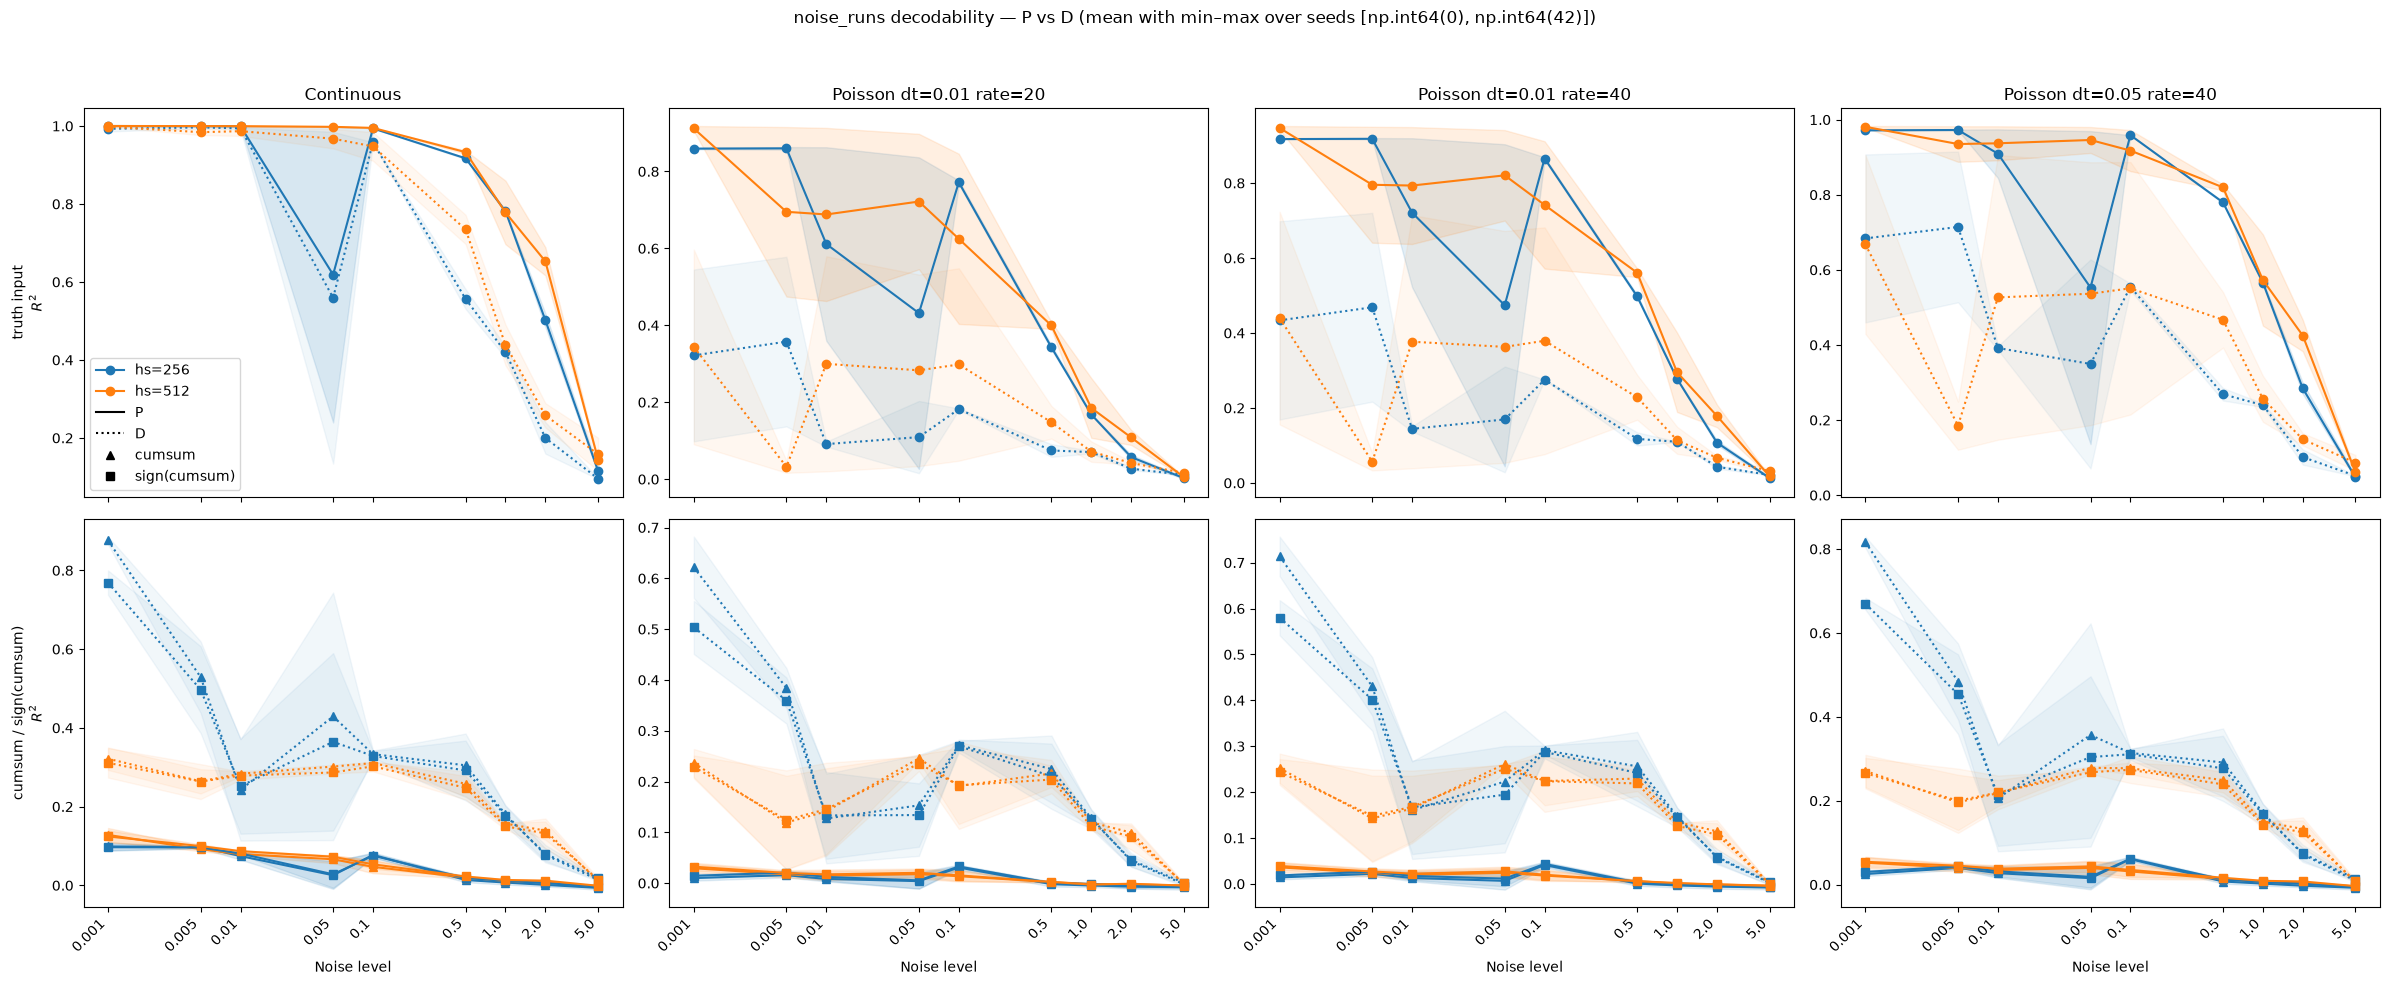

In [4]:
# noise_runs: R^2 vs noise, colored by hidden size
plot_decodability(
    noise_df,
    x_col="noise_p",
    group_col="hidden_size",
    group_prefix="hs",
    xlabel="Noise level",
    title="noise_runs decodability — P vs D",
)


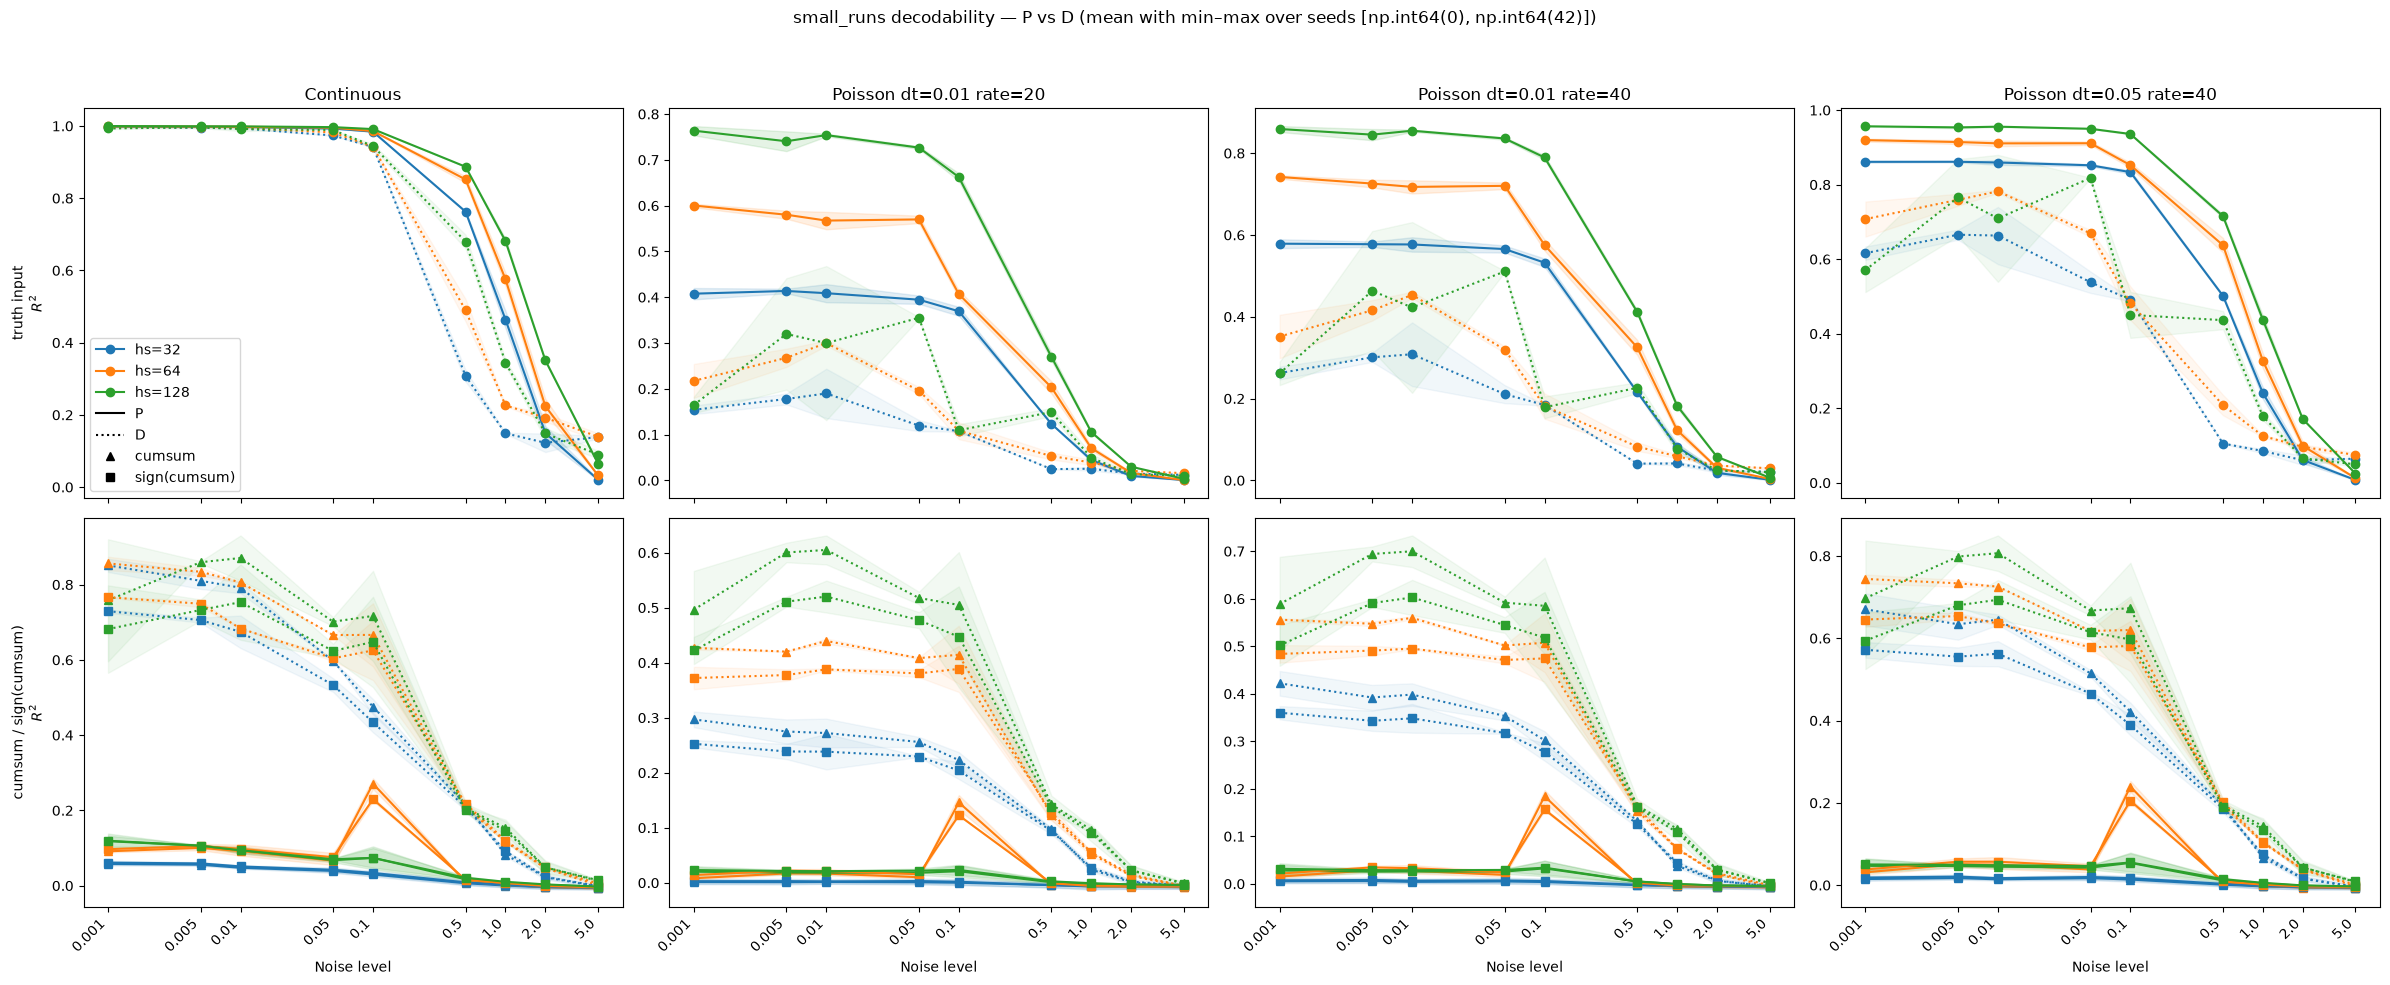

In [5]:
# small_runs: R^2 vs noise, colored by hidden size
plot_decodability(
    small_df,
    x_col="noise_p",
    group_col="hidden_size",
    group_prefix="hs",
    xlabel="Noise level",
    title="small_runs decodability — P vs D",
)
